In [1]:
import ee
import geemap
from dotenv import load_dotenv
import os
import ipywidgets as widgets
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd

load_dotenv(dotenv_path='.env')
project_name = os.getenv("project_name")
# print(f"Project Name: {project_name}")
ee.Initialize(project=project_name)

In [2]:
Map = geemap.Map()

country = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017") \
    .filter(ee.Filter.eq('country_na', 'Bangladesh'))

Map.centerObject(country, 7)
Map.add_basemap('SATELLITE')

In [3]:
lights2014 = ee.ImageCollection("NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG") \
    .filterDate('2014-01-01', '2014-12-31') \
    .select('avg_rad') \
    .median() \
    .clip(country)

lights2014 = ee.ImageCollection("NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG") \
    .filterDate('2014-01-01', '2014-12-31') \
    .select('avg_rad') \
    .median() \
    .clip(country)

lights2020 = ee.ImageCollection("NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG") \
    .filterDate('2020-01-01', '2020-12-31') \
    .select('avg_rad') \
    .median() \
    .clip(country)

lights2024 = ee.ImageCollection("NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG") \
    .filterDate('2024-01-01', '2024-12-31') \
    .select('avg_rad') \
    .median() \
    .clip(country)

growthMap = ee.Image.cat([
    lights2014.rename('Red'),  
    lights2024.rename('Green'),  
    lights2020.rename('Blue')    
])



In [4]:
visParams = {
    'min': 0,
    'max': 10, #lower = brighter
}

Map.addLayer(ee.Image(0), {'palette': ['000000']}, 'Black Background') 
Map.addLayer(growthMap, visParams, 'Light growth')

Map

Map(center=[23.845740439422947, 90.28182335177775], controls=(WidgetControl(options=['position', 'transparent_…

In [5]:
#slide part
slide_map = geemap.Map()
slide_map.centerObject(country, 7)
slide_map.add_basemap('SATELLITE')


left_layer = geemap.ee_tile_layer(lights2014, visParams, '2014 Lights')
right_layer = geemap.ee_tile_layer(lights2024, visParams, '2024 Lights')

slide_map.split_map(left_layer, right_layer)
slide_map

Map(center=[23.845740439422947, 90.28182335177775], controls=(ZoomControl(options=['position', 'zoom_in_text',…

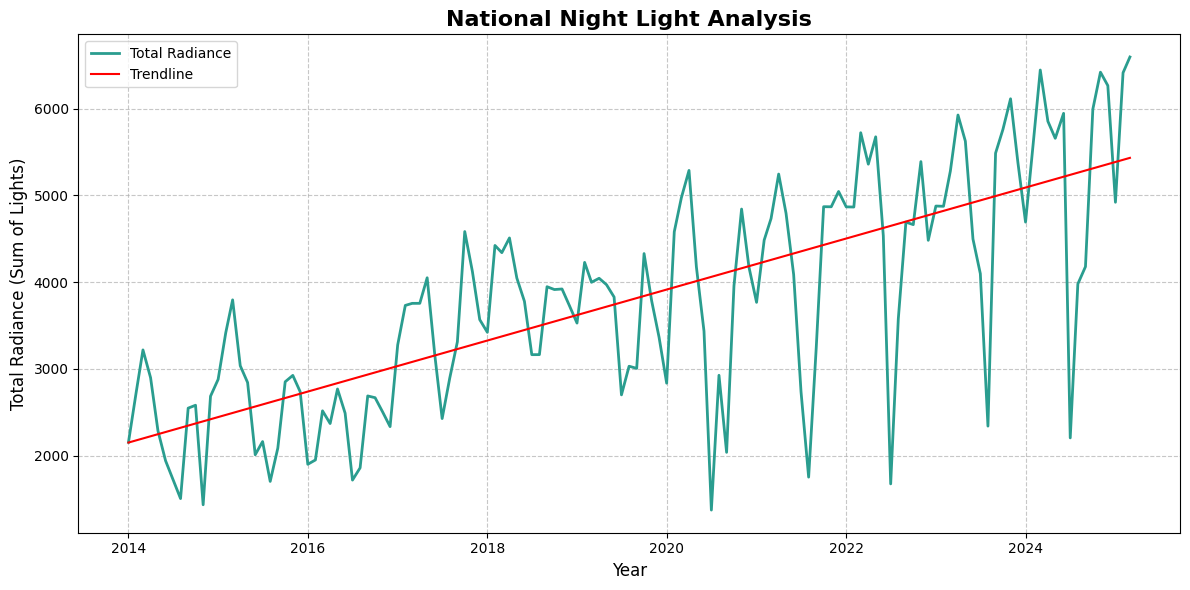

map

In [6]:
viirs = ee.ImageCollection("NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG") \
    .select('avg_rad')
#here the entire time range is selected


def reduce_lights(image):
    #calculating light over the time
    stats = image.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=country,
        scale=5000,  
        maxPixels=1e9
    )
    #return a feature with date and sum of lights
    return ee.Feature(None, {
        'date': image.date().format('YYYY-MM-dd'),
        'sum': stats.get('avg_rad'),
        'system:time_start': image.get('system:time_start')
    })

time_series = viirs.map(reduce_lights)

time_series = time_series.filter(ee.Filter.notNull(['sum']))

data_list = time_series.reduceColumns(
    ee.Reducer.toList(2), ['date', 'sum']
).get('list').getInfo()
#pulling the data to the sum of lights

df = pd.DataFrame(data_list, columns=['date', 'sum'])
df['date'] = pd.to_datetime(df['date'])
df['sum'] = pd.to_numeric(df['sum'])
df = df.sort_values('date')
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['sum'], color='#2A9D8F', linewidth=2, label='Total Radiance')
import numpy as np
z = np.polyfit(df['date'].map(pd.Timestamp.toordinal), df['sum'], 1)
p = np.poly1d(z)
plt.plot(df['date'], p(df['date'].map(pd.Timestamp.toordinal)), color='red', linestyle='-', label='Trendline')
plt.title('National Night Light Analysis', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Radiance (Sum of Lights)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
map